<a href="https://colab.research.google.com/github/thisisaadi123/Stock-forecasting/blob/main/Stock_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import math
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input

df = pd.read_csv('SPY.csv')
print(df.head())

                       date   close    high     low    open     volume  \
0  2010-01-04T00:00:00.000Z  113.33  113.39  111.51  112.37  118857369   
1  2010-01-05T00:00:00.000Z  113.63  113.68  112.85  113.26  111519230   
2  2010-01-06T00:00:00.000Z  113.71  113.99  113.43  113.52  116017127   
3  2010-01-07T00:00:00.000Z  114.19  114.33  113.18  113.50  130502017   
4  2010-01-08T00:00:00.000Z  114.57  114.62  113.66  113.89  126357911   

    adjClose    adjHigh     adjLow    adjOpen  adjVolume  divCash  splitFactor  
0  84.726201  84.771057  83.365558  84.008499  118857369      0.0          1.0  
1  84.950483  84.987863  84.367350  84.673868  111519230      0.0          1.0  
2  85.010291  85.219621  84.800961  84.868246  116017127      0.0          1.0  
3  85.369142  85.473807  84.614060  84.853294  130502017      0.0          1.0  
4  85.653232  85.690613  84.972911  85.144860  126357911      0.0          1.0  


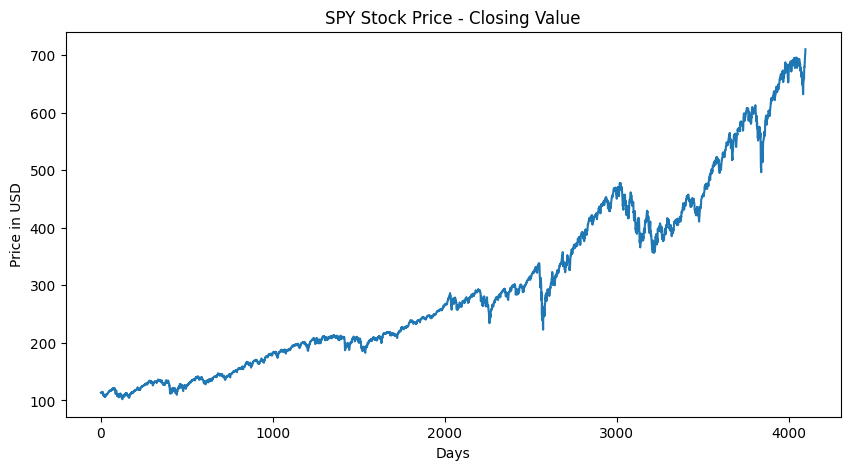

In [14]:
df1 = df.reset_index()['close']

plt.figure(figsize=(10,5))
plt.plot(df1)
plt.title(f'{ticker} Stock Price - Closing Value')
plt.xlabel('Days')
plt.ylabel('Price in USD')
plt.show()

In [15]:
scaler = MinMaxScaler(feature_range=(0,1))
df1_scaled = scaler.fit_transform(np.array(df1).reshape(-1,1))

# Split Dataset (65% Train, 35% Test)
training_size = int(len(df1_scaled) * 0.65)
test_size = len(df1_scaled) - training_size
train_data = df1_scaled[0:training_size, :]
test_data = df1_scaled[training_size:len(df1_scaled), :1]

print("Train data size:", len(train_data))
print("Test data size:", len(test_data))

Train data size: 2663
Test data size: 1434


In [16]:
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (2562, 100, 1)
X_test shape: (1333, 100, 1)


In [17]:
model = Sequential()
model.add(Input(shape=(100, 1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

model.summary()
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64, verbose=2)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
41/41 - 3s - 81ms/step - loss: 0.0039 - val_loss: 5.9538e-04
Epoch 2/100
41/41 - 1s - 19ms/step - loss: 1.5591e-04 - val_loss: 0.0021
Epoch 3/100
41/41 - 1s - 18ms/step - loss: 1.3073e-04 - val_loss: 0.0018
Epoch 4/100
41/41 - 1s - 21ms/step - loss: 1.2258e-04 - val_loss: 0.0038
Epoch 5/100
41/41 - 2s - 39ms/step - loss: 1.3694e-04 - val_loss: 0.0014
Epoch 6/100
41/41 - 1s - 20ms/step - loss: 1.1490e-04 - val_loss: 0.0023
Epoch 7/100
41/41 - 1s - 18ms/step - loss: 1.0910e-04 - val_loss: 0.0027
Epoch 8/100
41/41 - 1s - 18ms/step - loss: 1.0238e-04 - val_loss: 0.0016
Epoch 9/100
41/41 - 1s - 18ms/step - loss: 9.6558e-05 - val_loss: 0.0030
Epoch 10/100
41/41 - 1s - 18ms/step - loss: 9.2984e-05 - val_loss: 0.0023
Epoch 11/100
41/41 - 1s - 18ms/step - loss: 8.7757e-05 - val_loss: 0.0039
Epoch 12/100
41/41 - 1s - 19ms/step - loss: 1.0827e-04 - val_loss: 0.0012
Epoch 13/100
41/41 - 1s - 18ms/step - loss: 9.4452e-05 - val_loss: 0.0022
Epoch 14/100
41/41 - 1s - 18ms/step - loss: 7.5

In [18]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_real = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Train RMSE (USD): ", math.sqrt(mean_squared_error(y_train_real, train_predict)))
print("Test RMSE (USD): ", math.sqrt(mean_squared_error(y_test_real, test_predict)))

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Train RMSE (USD):  2.831221431033534
Test RMSE (USD):  33.82945319480466


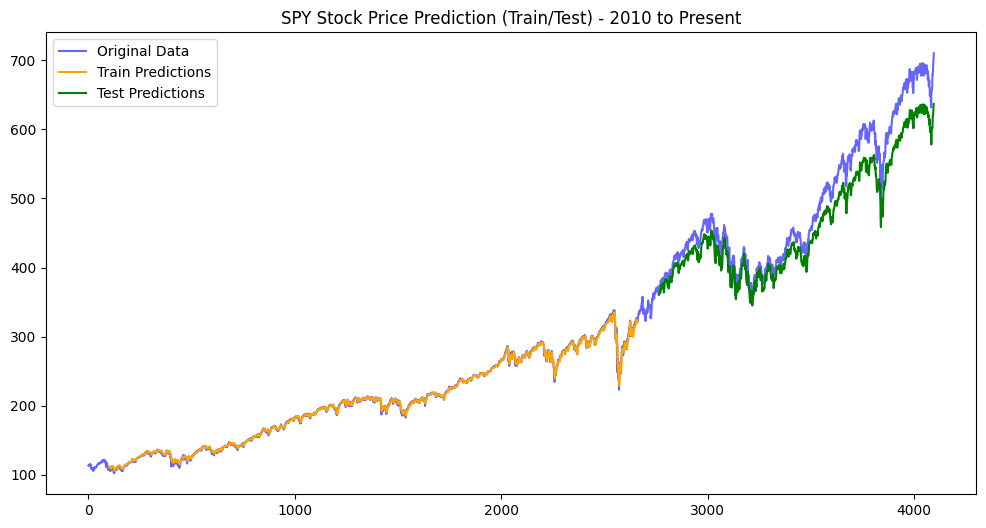

In [19]:
look_back = 100

plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(df1_scaled), label='Original Data', color='blue', alpha=0.6)

# Plotting Train Predictions
trainPredictPlot = np.empty_like(df1_scaled)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
plt.plot(trainPredictPlot, label='Train Predictions', color='orange')

# Plotting Test Predictions
testPredictPlot = np.empty_like(df1_scaled)
testPredictPlot[:, :] = np.nan
start_idx = len(train_predict) + (look_back * 2) + 1
testPredictPlot[start_idx:len(df1_scaled)-1, :] = test_predict
plt.plot(testPredictPlot, label='Test Predictions', color='green')

plt.title(f'{ticker} Stock Price Prediction (Train/Test) - 2010 to Present')
plt.legend()
plt.show()

In [20]:
x_input = test_data[-100:].reshape(1, -1)
temp_input = list(x_input)
temp_input = temp_input[0].tolist()

lst_output = []
n_steps = 100
i = 0

while(i < 30):
    if(len(temp_input) > 100):
        x_input = np.array(temp_input[1:])
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = model.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        temp_input = temp_input[1:]
        lst_output.extend(yhat.tolist())
        i = i + 1
    else:
        x_input = x_input.reshape((1, n_steps, 1))
        yhat = model.predict(x_input, verbose=0)
        temp_input.extend(yhat[0].tolist())
        lst_output.extend(yhat.tolist())
        i = i + 1

print("30 future days predicted successfully.")

30 future days predicted successfully.


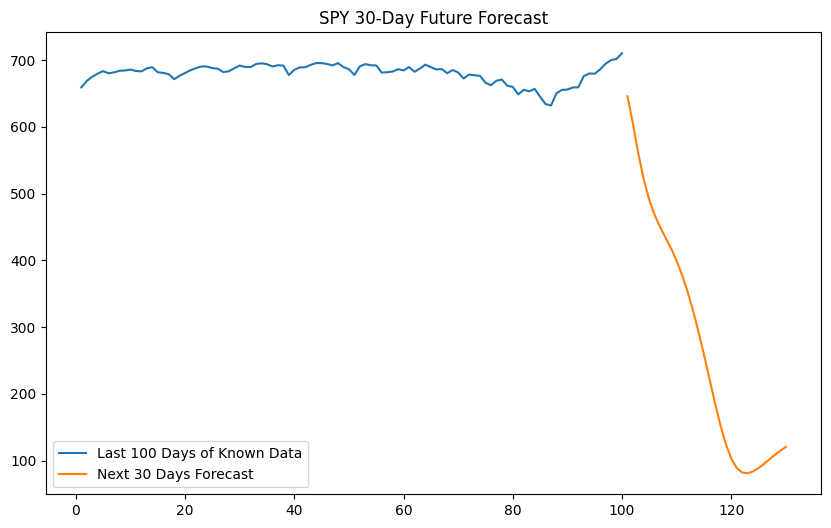

In [21]:
day_new = np.arange(1, 101)
day_pred = np.arange(101, 131)

last_100_days = df1_scaled[-100:]

plt.figure(figsize=(10,6))
plt.plot(day_new, scaler.inverse_transform(last_100_days), label='Last 100 Days of Known Data')
plt.plot(day_pred, scaler.inverse_transform(lst_output), label='Next 30 Days Forecast')
plt.title(f'{ticker} 30-Day Future Forecast')
plt.legend()
plt.show()

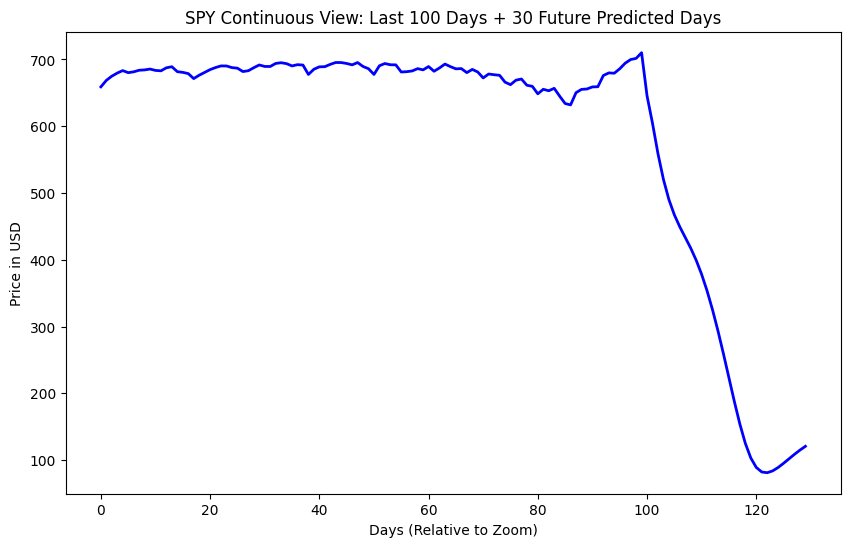

In [22]:
df3 = df1_scaled.flatten().tolist()
flat_lst_output = [item for sublist in lst_output for item in sublist]
df3.extend(flat_lst_output)
df3_real_dollars = scaler.inverse_transform(np.array(df3).reshape(-1, 1))
zoom_index = len(df1_scaled) - 100
plt.figure(figsize=(10,6))
plt.plot(df3_real_dollars[zoom_index:], color='blue', linewidth=2)
plt.title(f'{ticker} Continuous View: Last 100 Days + 30 Future Predicted Days')
plt.xlabel('Days (Relative to Zoom)')
plt.ylabel('Price in USD')
plt.show()